In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from IPython.display import Markdown


df = pd.read_csv("bank_transactions.csv")

#Visão geral
display(df.shape)
display(df.dtypes)
display(df.isnull().sum())
display(df.head())

#Conversão de datas
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

#estatistica descritivas das colunas numéricas
display (
    df[['TransactionAmount', 'CustomerAge', 'TransactionDuration',
    'LoginAttempts', 'AccountBalance']].describe()
)



(2512, 16)

TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,530.14,2023-04-11 10:23:00,Credit,Seattle,D000380,162.198.218.92,M015,ATM,40,Doctor,81,1,17036.94,2024-11-04 08:08:08
1,TX000002,AC00455,45.99,2023-06-27 09:09:00,Credit,Houston,D000051,13.149.61.4,M052,Online,34,Unemployed,141,1,783.57,2024-11-04 08:09:35
2,TX000003,AC00019,45.46,2023-07-10 18:14:00,Transfer,Los Angeles,D000235,215.97.143.157,M009,Online,23,Student,56,1,1254.24,2024-11-04 08:07:04
3,TX000004,AC00070,181.71,2023-05-05 14:37:00,Payment,New York,D000187,200.13.225.150,M002,Online,18,Student,25,1,2222.58,2024-11-04 08:09:06
4,TX000005,AC00411,57.34,2023-10-16 10:19:00,Debit,Phoenix,D000308,65.164.3.100,M091,Online,40,Engineer,198,1,9287.07,2024-11-04 08:06:39


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,537.302735,37.076035,119.643312,1.325239,10005.731278
std,1006.544318,14.317981,69.963757,0.815345,7633.045682
min,0.020000,18.000000,10.000000,1.000000,13.090000
25%,133.105000,26.000000,63.000000,1.000000,2581.237500
50%,317.175000,35.000000,112.500000,1.000000,9412.980000
75%,594.437500,44.000000,161.000000,1.000000,14907.540000
max,9450.650000,80.000000,300.000000,5.000000,39638.380000


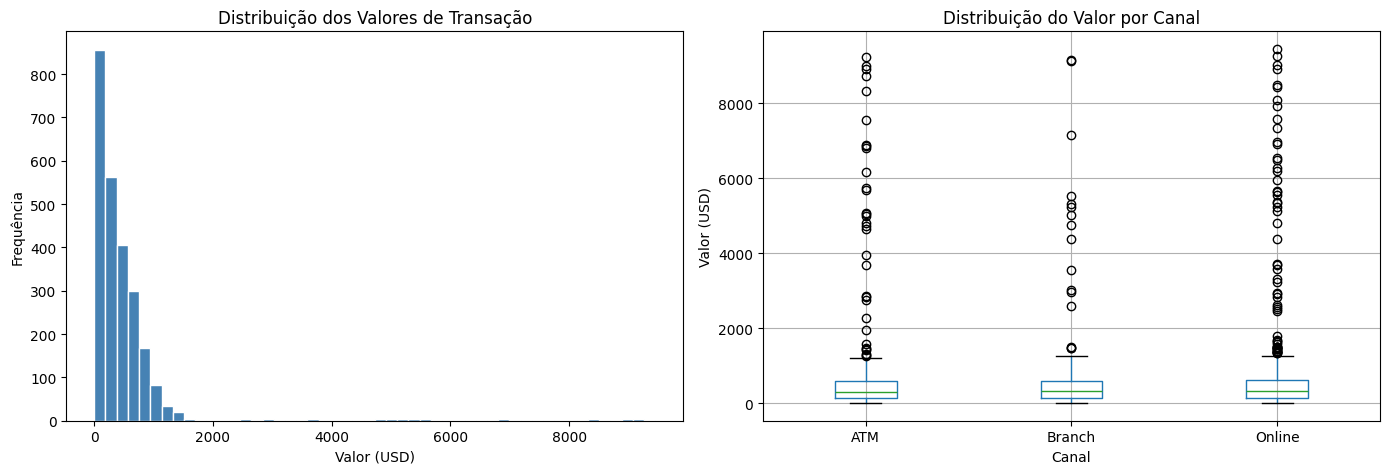

,mean,median,max
Channel,,,
ATM,558.74,299.17,9247.93
Branch,508.73,321.05,9167.51
Online,536.33,326.24,9450.65


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['TransactionAmount'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição dos Valores de Transação')
axes[0].set_xlabel('Valor (USD)')
axes[0].set_ylabel('Frequência')

# Boxplot por canal
df.boxplot(column='TransactionAmount', by='Channel', ax=axes[1])
axes[1].set_title('Distribuição do Valor por Canal')
axes[1].set_xlabel('Canal')
axes[1].set_ylabel('Valor (USD)')
fig.suptitle('')

plt.tight_layout()
plt.savefig('distribuicao_valores.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Resumo por canal
df.groupby('Channel')['TransactionAmount'].agg(['mean', 'median', 'max']).round(2)

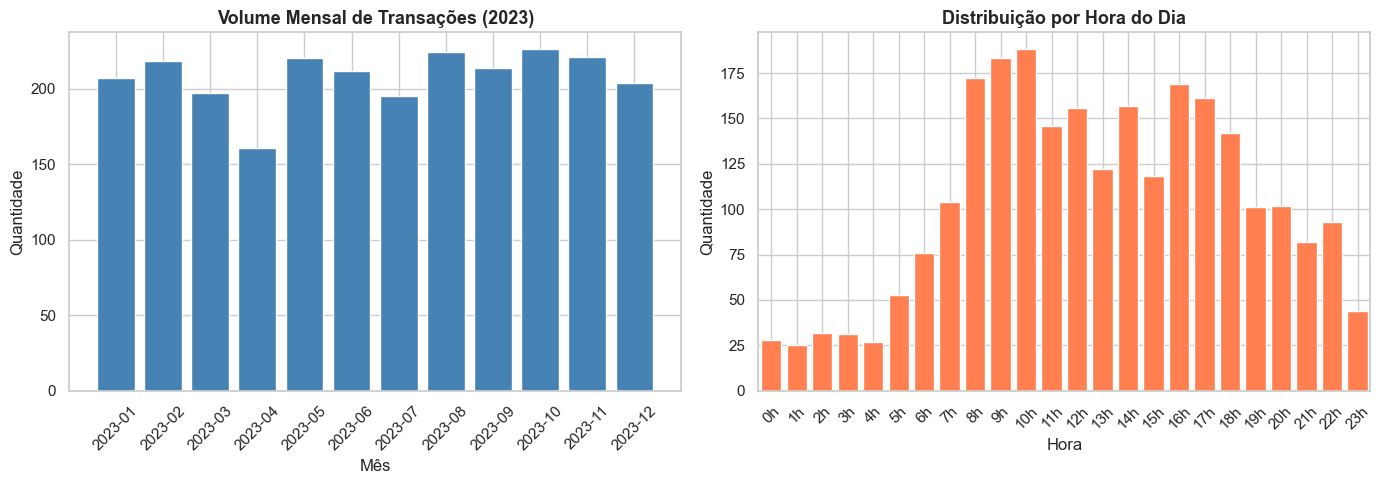

Hora,Quantidade,% do Total
0h,28,1.1%
1h,25,1.0%
2h,32,1.3%
3h,31,1.2%
4h,27,1.1%
5h,53,2.1%
6h,76,3.0%
7h,104,4.1%
8h,172,6.8%
9h,183,7.3%



**Mês com maior volume:** 2023-10 — 226 transações  
**Mês com menor volume:** 2023-04 — 161 transações  


In [12]:
sns.set_theme(style="whitegrid")
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df['hour'] = df['TransactionDate'].dt.hour
df['month'] = df['TransactionDate'].dt.to_period('M')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume por mês
monthly = df[df['TransactionDate'].dt.year == 2023].groupby('month').size()
axes[0].bar(monthly.index.astype(str), monthly.values, color='steelblue')
axes[0].set_title('Volume Mensal de Transações (2023)')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)

# Volume por hora do dia
hourly = df.groupby('hour').size().sort_index() 
axes[1].bar(hourly.index, hourly.values, color='coral')
axes[1].set_title('Distribuição por Hora do Dia')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Quantidade')
axes[1].set_xticks(hourly.index)
axes[1].set_xticklabels([f'{h}h' for h in hourly.index], rotation=45)
axes[1].set_xlim(hourly.index.min() - 0.5, hourly.index.max() + 0.5)

plt.tight_layout()
plt.savefig('analise_temporal.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Tabela ordenada por hora
resumo_horas = (df.groupby('hour')
                  .size()
                  .reset_index(name='Quantidade')
                  .sort_values('hour'))  

resumo_horas.columns = ['Hora', 'Quantidade']
resumo_horas['% do Total'] = (resumo_horas['Quantidade'] / len(df) * 100).round(1)
resumo_horas['Hora'] = resumo_horas['Hora'].astype(str) + 'h'

display(resumo_horas.style
        .set_caption('Volume de Transações por Hora do Dia')
        .format({'% do Total': '{:.1f}%'})
        .hide(axis='index'))

# Destaques
display(Markdown(f"""
**Mês com maior volume:** {monthly.idxmax()} — {monthly.max()} transações  
**Mês com menor volume:** {monthly.idxmin()} — {monthly.min()} transações  
"""))

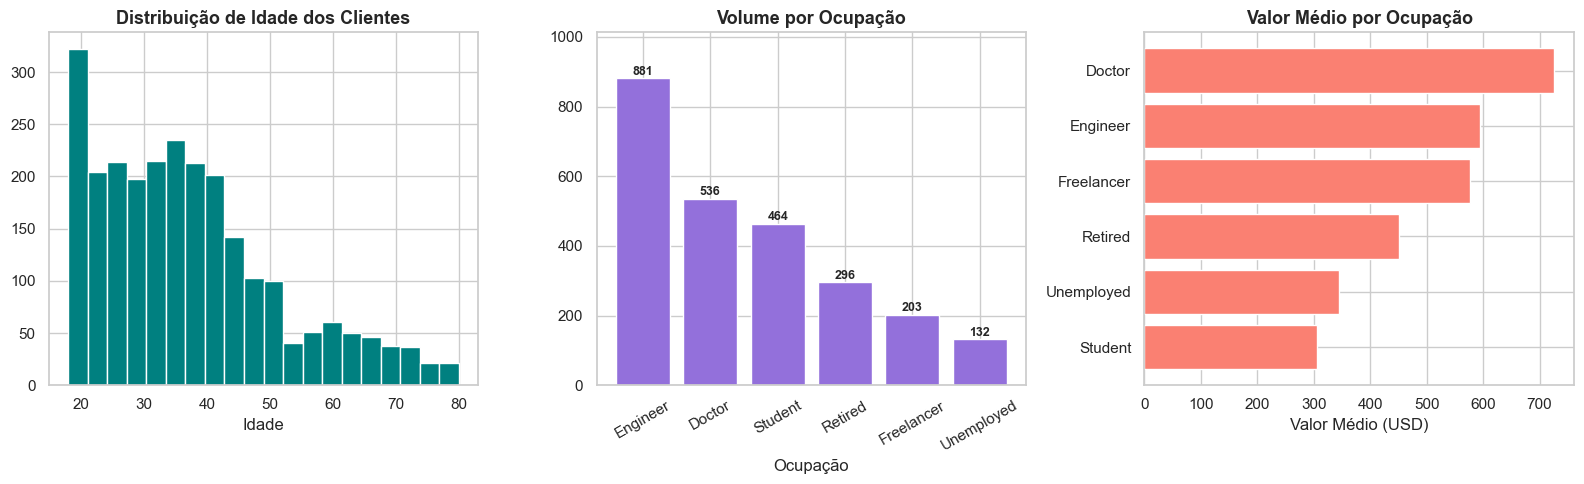

,CustomerAge,TransactionAmount,AccountBalance
CustomerAge,1.00,0.03,0.27
TransactionAmount,0.03,1.00,0.12
AccountBalance,0.27,0.12,1.00


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribuição de idade
axes[0].hist(df['CustomerAge'], bins=20, color='teal', edgecolor='white')
axes[0].set_title('Distribuição de Idade dos Clientes')
axes[0].set_xlabel('Idade')

# Transações por ocupação
occ_count = df['CustomerOccupation'].value_counts()
axes[1].bar(occ_count.index, occ_count.values, color='mediumpurple')
axes[1].set_title('Volume por Ocupação')
axes[1].set_xlabel('Ocupação')
axes[1].tick_params(axis='x', rotation=30) 
for i, v in enumerate(occ_count.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylim(0, occ_count.values.max() * 1.15)

# Valor médio por ocupação
occ_amount = df.groupby('CustomerOccupation')['TransactionAmount'].mean().sort_values()
axes[2].barh(occ_amount.index, occ_amount.values, color='salmon')
axes[2].set_title('Valor Médio por Ocupação')
axes[2].set_xlabel('Valor Médio (USD)')

plt.tight_layout()
plt.show()

# Correlação idade x valor
corr = df[['CustomerAge', 'TransactionAmount', 'AccountBalance']].corr()

display(
    corr.style
        .background_gradient(cmap='coolwarm', axis=None)
        .format("{:.2f}")
)

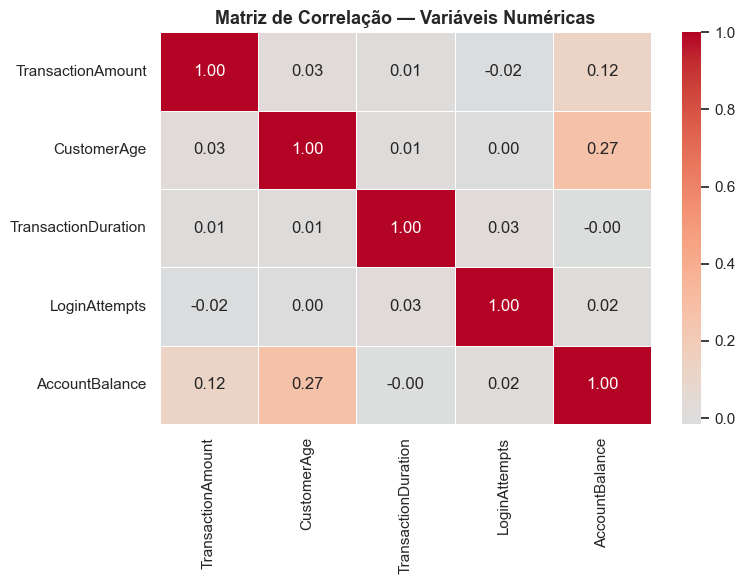

In [5]:
numeric_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
                'LoginAttempts', 'AccountBalance']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title('Matriz de Correlação — Variáveis Numéricas')
plt.tight_layout()
plt.show()

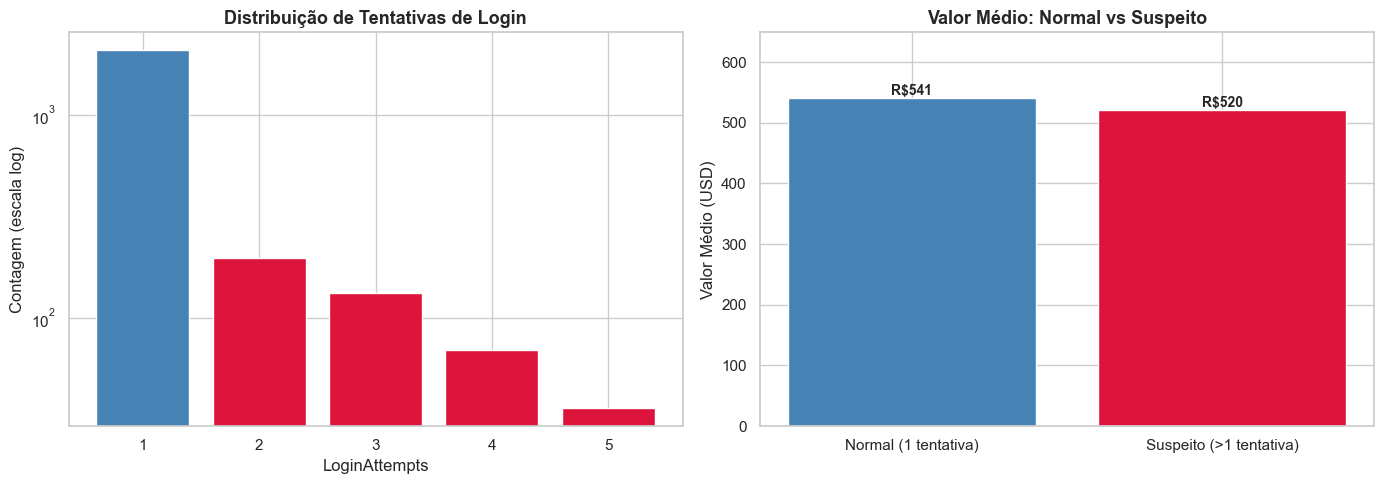


**Transações suspeitas:** 436 (17.4% do total)  
**Valor médio normal:** R$541  
**Valor médio suspeito:** R$520


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de tentativas de login
login_dist = df['LoginAttempts'].value_counts().sort_index()
axes[0].bar(login_dist.index, login_dist.values,
            color=['steelblue' if i == 1 else 'crimson' for i in login_dist.index])
axes[0].set_title('Distribuição de Tentativas de Login')
axes[0].set_xlabel('LoginAttempts')
axes[0].set_ylabel('Contagem (escala log)')
axes[0].set_yscale('log')
axes[0].set_xticks(login_dist.index)

# Valor médio: suspeito vs normal
avg_by_suspicious = df.groupby('suspicious')['TransactionAmount'].mean()
bars = axes[1].bar(['Normal (1 tentativa)', 'Suspeito (>1 tentativa)'],
                    avg_by_suspicious.values,
                    color=['steelblue', 'crimson'])
axes[1].set_title('Valor Médio: Normal vs Suspeito')
axes[1].set_ylabel('Valor Médio (USD)')
axes[1].set_ylim(0, avg_by_suspicious.values.max() * 1.2)

for i, v in enumerate(avg_by_suspicious.values):
    axes[1].text(i, v + 5, f'R${v:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('login_suspeitos.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Classificação de suspeitos
# Rodar APÓS o plt.show()
display(Markdown(f"""
**Transações suspeitas:** {df['suspicious'].sum()} ({df['suspicious'].mean()*100:.1f}% do total)  
**Valor médio normal:** R${avg_by_suspicious[False]:.0f}  
**Valor médio suspeito:** R${avg_by_suspicious[True]:.0f}
"""))

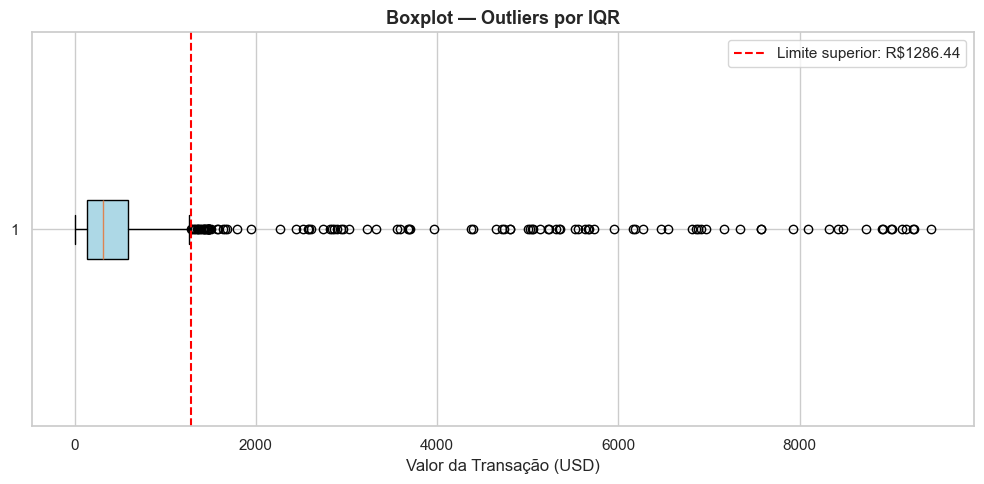

**Outliers detectados por IQR:** 105 (4.2% do total) — transações acima de R$1286.44

In [ ]:
# Cálculo dos quartis e limites do IQR
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1

# Limites: transações fora desse intervalo são classificadas como outliers
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Filtrando outliers
outliers_iqr = df[
    (df['TransactionAmount'] < lower) |
    (df['TransactionAmount'] > upper)
]


plt.figure(figsize=(10, 5))

plt.boxplot(df['TransactionAmount'],
            vert=False,
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'))

plt.axvline(x=upper, color='red', linestyle='--',
            label=f'Limite superior: R${upper:.2f}')

plt.title('Boxplot — Outliers por IQR')
plt.xlabel('Valor da Transação (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('outliers_iqr.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Resultado
display(Markdown(
    f"**Outliers detectados por IQR:** {len(outliers_iqr)} "
    f"({len(outliers_iqr)/len(df)*100:.1f}% do total) — "
    f"transações acima de R${upper:.2f}"
))

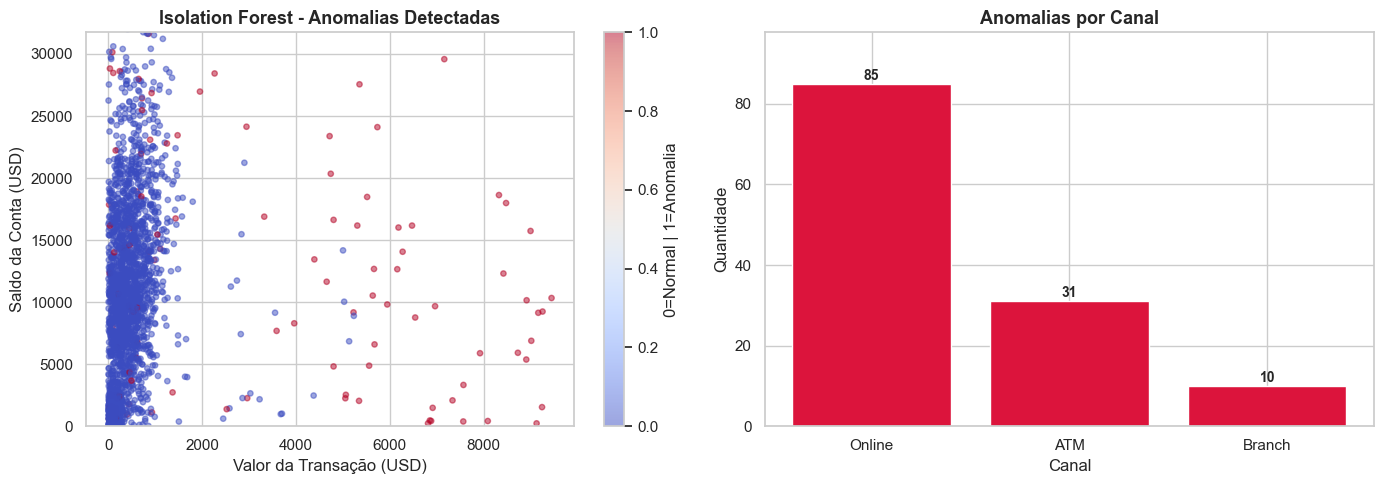

**Anomalias detectadas:** 126 (5.0% do total)

In [30]:
from sklearn.ensemble import IsolationForest

features = df[['TransactionAmount', 'LoginAttempts', 'TransactionDuration',
               'AccountBalance', 'CustomerAge']].copy()

model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_score'] = model.fit_predict(features)
df['anomaly'] = df['anomaly_score'].apply(lambda x: 1 if x == -1 else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(df['TransactionAmount'], df['AccountBalance'],
                          c=df['anomaly'], cmap='coolwarm', alpha=0.5, s=15)
axes[0].set_title('Isolation Forest - Anomalias Detectadas')
axes[0].set_xlabel('Valor da Transação (USD)')
axes[0].set_ylabel('Saldo da Conta (USD)')
axes[0].set_ylim(0, df['AccountBalance'].quantile(0.99))
plt.colorbar(scatter, ax=axes[0], label='0=Normal | 1=Anomalia')

anomalias = df[df['anomaly'] == 1]
canal_anomalia = anomalias['Channel'].value_counts()
axes[1].bar(canal_anomalia.index, canal_anomalia.values, color='crimson')
axes[1].set_title('Anomalias por Canal')
axes[1].set_xlabel('Canal')
axes[1].set_ylabel('Quantidade')
axes[1].set_ylim(0, canal_anomalia.values.max() * 1.15)
for i, v in enumerate(canal_anomalia.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('isolation_forest.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

display(Markdown(
    f"**Anomalias detectadas:** {df['anomaly'].sum()} "
    f"({df['anomaly'].mean()*100:.1f}% do total)"
))